In [ ]:
# Earthquake Hotspot Detection (Geospatial Clustering)

         Date      Time  Latitude  Longitude        Type  Depth  Depth Error  \
0  01/02/1965  13:44:18    19.246    145.616  Earthquake  131.6          NaN   
1  01/04/1965  11:29:49     1.863    127.352  Earthquake   80.0          NaN   
2  01/05/1965  18:05:58   -20.579   -173.972  Earthquake   20.0          NaN   
3  01/08/1965  18:49:43   -59.076    -23.557  Earthquake   15.0          NaN   
4  01/09/1965  13:32:50    11.938    126.427  Earthquake   15.0          NaN   

   Depth Seismic Stations  Magnitude Magnitude Type  ...  \
0                     NaN        6.0             MW  ...   
1                     NaN        5.8             MW  ...   
2                     NaN        6.2             MW  ...   
3                     NaN        5.8             MW  ...   
4                     NaN        5.8             MW  ...   

   Magnitude Seismic Stations  Azimuthal Gap  Horizontal Distance  \
0                         NaN            NaN                  NaN   
1                   

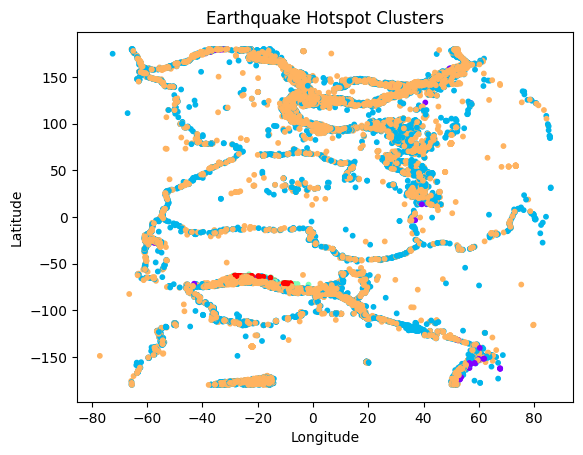

cluster
 0    12852
 2    10410
-1       63
 3       45
 1       42
Name: count, dtype: int64


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN

# load dataset

df = pd.read_csv("database.csv")

print(df.head())
print(df.info())

# convert data caterigocal to numerical

le = LabelEncoder()
df["Magnitude Source"] = le.fit_transform(df["Magnitude Source"].astype(str))


# input features

features = df[["Latitude","Longitude","Depth","Magnitude Source"]]

# features scaling

scaling = StandardScaler()
x_scale = scaling.fit_transform(features)

# Apply dbscan

model = DBSCAN(eps = 0.5, min_samples = 10)
model.fit(x_scale)
df["cluster"] = model.labels_

#visulization

plt.scatter(df['Latitude'],df['Longitude'], c = df['cluster'], cmap ='rainbow', s = 10)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Hotspot Clusters")
plt.show()
print(df['cluster'].value_counts())


In [ ]:
#Earth Observation – Forest Fire Cluster Detection

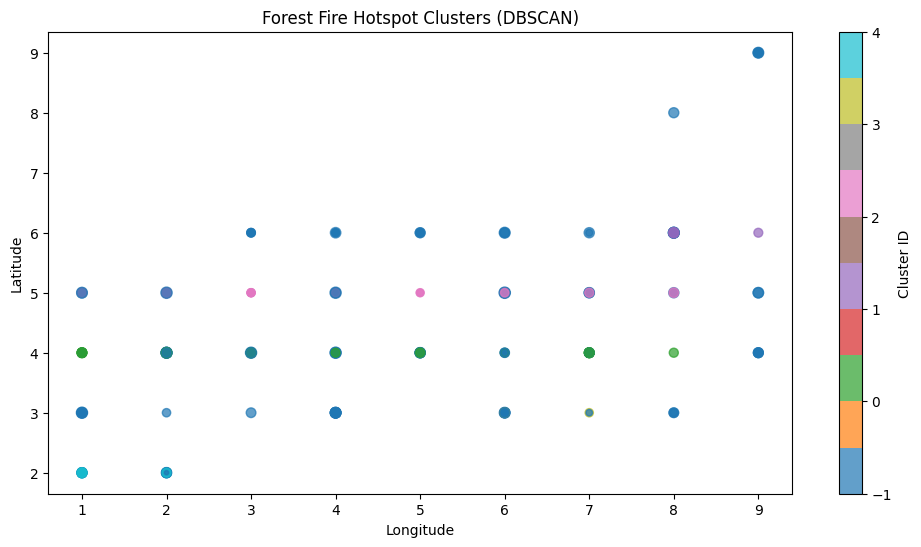

              temp       area
cluster                      
-1       18.735583  32.667914
 0       18.748214   3.657500
 1       20.335714   6.415000
 2       18.140625   3.548021
 3       18.913333   3.213333
 4       20.690909   1.347879


In [12]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

#load dataset

data = pd.read_csv("forestfires.csv")

data.rename(columns = {'X':'Longitude', 'Y':'Latitude'}, inplace = True)

features = data[['Longitude', 'Latitude','temp','area']]

#scaling features

scaling = StandardScaler()
x_scale = scaling.fit_transform(features)

# applying dbscan

z = DBSCAN(eps = 0.5, min_samples = 10)
model = z.fit(x_scale)
data['cluster'] =model.labels_

# visulization
plt.figure(figsize = [12, 6])
scatter = plt. scatter(data['Longitude'], data['Latitude'], c = data['cluster'], cmap = 'tab10', s=data['temp']*2, alpha = 0.7)
plt.colorbar(scatter, label='Cluster ID')
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Forest Fire Hotspot Clusters (DBSCAN)")
plt.show()

print(data.groupby('cluster')[['temp','area']].mean())
